# 1. Setup and Get Data

### 1.1 Install Dependencies and Setup

In [6]:
!pip install labelme tensorflow opencv-python matplotlib albumentations


[notice] A new release of pip is available: 23.1.2 -> 23.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1.2 Collect Images Using OpenCV

In [7]:
import os
import time
import uuid
import cv2

In [8]:
IMAGES_PATH = os.path.join('data','images')
number_images = 30

In [9]:
for image_num in range(30):
    print(image_num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [9]:
cap = cv2.VideoCapture(0)
for imgnum in range(number_images):
    print('Collecting image {}'.format(imgnum))
    ret, frame = cap.read()
    imgname = os.path.join(IMAGES_PATH,f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname, frame)
    cv2.imshow('frame', frame)
    time.sleep(0.5)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

### 1.3 Annotate Images with LabelMe

In [11]:
!labelme

[INFO   ] __init__:get_config:70 - Loading config file from: C:\Users\USER\.labelmerc


# 2. Review Dataset and Build Image Loading Function

### 2.1 Import TF and Deps

In [10]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt

### 2.2 Limit GPU Memory Growth

In [12]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [13]:
tf.config.list_physical_devices('GPU')

[]

### 2.3 Load Image into TF Data Pipeline

In [14]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg')

In [18]:
images.as_numpy_iterator().next()

b'data\\images\\1f39a5f0-5062-11ee-af8c-50eb717060f1.jpg'

In [19]:
def load_image(x): 
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [20]:
images = images.map(load_image)

In [21]:
images.as_numpy_iterator().next()

array([[[146, 148, 147],
        [147, 149, 148],
        [148, 148, 148],
        ...,
        [134, 134, 134],
        [134, 134, 134],
        [134, 134, 134]],

       [[146, 148, 147],
        [146, 148, 147],
        [147, 147, 147],
        ...,
        [134, 134, 134],
        [135, 135, 135],
        [137, 137, 137]],

       [[144, 149, 145],
        [144, 149, 145],
        [146, 148, 145],
        ...,
        [135, 135, 135],
        [136, 136, 136],
        [138, 138, 138]],

       ...,

       [[ 68,  69,  64],
        [ 67,  68,  63],
        [ 66,  67,  62],
        ...,
        [105, 107, 128],
        [106, 108, 129],
        [106, 108, 129]],

       [[ 66,  66,  64],
        [ 66,  66,  64],
        [ 67,  67,  65],
        ...,
        [104, 106, 129],
        [103, 105, 128],
        [103, 105, 128]],

       [[ 69,  69,  67],
        [ 70,  70,  68],
        [ 70,  70,  68],
        ...,
        [105, 107, 130],
        [104, 106, 129],
        [104, 106, 129]]

In [22]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

### 2.4 View Raw Images with Matplotlib

In [23]:
image_generator = images.batch(4).as_numpy_iterator() 
#as_numpy_iterator will give the next batch of 4

In [26]:
plot_images = image_generator.next()

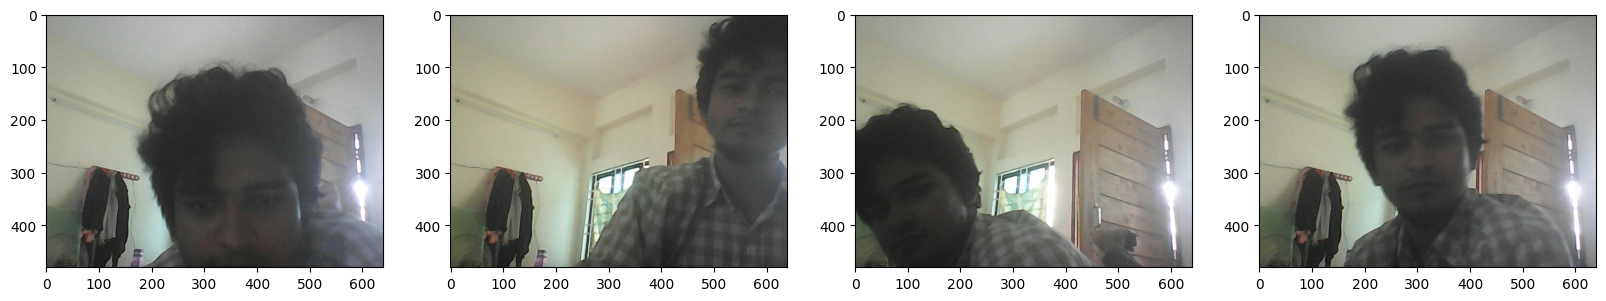

In [27]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image) 
plt.show()

# 3. Partition Unaugmented Data

### 3.1 MANUALLY SPLT DATA INTO TRAIN TEST AND VAL

In [28]:
90*.7 # 63 to train

62.99999999999999

In [29]:
90*.15 # 14 and 13 to test and val

13.5

### 3.2 Move the Matching Labels

In [30]:
for folder in ['train','test','val']:
    for file in os.listdir(os.path.join('data', folder, 'images')):
        
        filename = file.split('.')[0]+'.json'
        existing_filepath = os.path.join('data','labels', filename)
        if os.path.exists(existing_filepath): 
            new_filepath = os.path.join('data',folder,'labels',filename)
            os.replace(existing_filepath, new_filepath)      

# 4. Apply Image Augmentation on Images and Labels using Albumentations

### 4.1 Setup Albumentations Transform Pipeline

In [31]:
import albumentations as alb

In [32]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height=450), 
                         alb.HorizontalFlip(p=0.5), 
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2), 
                         alb.RGBShift(p=0.2), 
                         alb.VerticalFlip(p=0.5)], 
                       bbox_params=alb.BboxParams(format='albumentations', 
                                                  label_fields=['class_labels']))

### 4.2 Load a Test Image and Annotation with OpenCV and JSON

In [35]:
img = cv2.imread(os.path.join('data','train', 'images','01f953a1-5062-11ee-ab92-50eb717060f1.jpg'))

In [37]:
with open(os.path.join('data', 'train', 'labels', '01f953a1-5062-11ee-ab92-50eb717060f1.json'), 'r') as f:
    label = json.load(f)

In [40]:
label['shapes'][0]['points']

[[205.19553072625698, 235.53072625698323], [512.8826174978217, 479.0]]

### 4.3 Extract Coordinates and Rescale to Match Image Resolution

In [41]:
coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [42]:
coords

[205.19553072625698, 235.53072625698323, 512.8826174978217, 479.0]

In [43]:
coords = list(np.divide(coords, [640,480,640,480]))

In [44]:
coords

[0.3206180167597765,
 0.4906890130353817,
 0.8013790898403463,
 0.9979166666666667]

### 4.4 Apply Augmentations and View Results

In [45]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])

In [47]:
augmented['bboxes'][0][2:]

(0.7284543761638733, 0.4765983860955928)

In [48]:
augmented['bboxes']

[(0.04470529444928517, 0.0, 0.7284543761638733, 0.4765983860955928)]

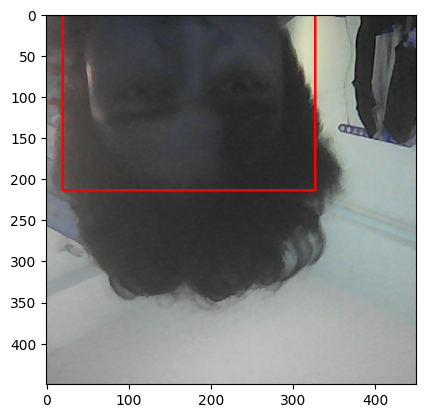

In [49]:
cv2.rectangle(augmented['image'], 
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)), 
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)), 
                    (255,0,0), 2)
            #topmost and bottom most
plt.imshow(augmented['image'])

# 5. Build and Run Augmentation Pipeline

### 5.1 Run Augmentation Pipeline

In [50]:
 #loop through train, test, val folder. if face isn't there then we assigned some values
for partition in ['train','test','val']: 
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        coords = [0,0,0.00001,0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)

            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [640,480,640,480]))

        try: 
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0: 
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = 0 
                    else: 
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else: 
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0 


                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(e)

image must be numpy array type
x_max is less than or equal to x_min for bbox [0.41663756983240213, 0.4697392923649907, 0.06485684357541895, 0.9364525139664805, 'face'].
x_max is less than or equal to x_min for bbox [0.3738652234636871, 0.5372439478584731, 0.003753491620111693, 0.9830074487895717, 'face'].
x_max is less than or equal to x_min for bbox [0.3633903631284915, 0.5547020484171322, 4.4408920985006264e-17, 0.9783757741111255, 'face'].
x_max is less than or equal to x_min for bbox [0.7003317039106145, 0.6163873370577282, 0.3915712661951741, 0.9979166666666667, 'face'].
x_max is less than or equal to x_min for bbox [0.8958624301675977, 0.43598696461824954, 0.5170216480446926, 0.9818435754189944, 'face'].
x_max is less than or equal to x_min for bbox [0.7797660614525139, 0.47788640595903165, 0.3406948324022346, 0.9946461824953445, 'face'].
x_max is less than or equal to x_min for bbox [0.5370984636871508, 0.5186219739292365, 0.2577688547486033, 0.8875698324022347, 'face'].
x_max i

### 5.2 Load Augmented Images to Tensorflow Dataset

In [51]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [52]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [53]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [54]:
train_images.as_numpy_iterator().next()

array([[[0.6779412 , 0.6622549 , 0.6661765 ],
        [0.6655637 , 0.65772057, 0.66164213],
        [0.672549  , 0.6647059 , 0.66862744],
        ...,
        [0.5955882 , 0.5720588 , 0.5877451 ],
        [0.6112745 , 0.5877451 , 0.60343134],
        [0.62561274, 0.6020833 , 0.6177696 ]],

       [[0.6806985 , 0.6601103 , 0.66648287],
        [0.68578434, 0.67009807, 0.67401963],
        [0.68235296, 0.6735294 , 0.67745095],
        ...,
        [0.63235295, 0.60882354, 0.6245098 ],
        [0.6348652 , 0.6113358 , 0.6270221 ],
        [0.63713235, 0.61360294, 0.6292892 ]],

       [[0.67873776, 0.6630515 , 0.66697305],
        [0.6852941 , 0.6696078 , 0.6735294 ],
        [0.6852941 , 0.6696078 , 0.6735294 ],
        ...,
        [0.63278186, 0.60925245, 0.6249387 ],
        [0.6308824 , 0.6073529 , 0.6230392 ],
        [0.6269608 , 0.60343134, 0.6191176 ]],

       ...,

       [[0.14491421, 0.12138481, 0.13707107],
        [0.14430147, 0.12077206, 0.1286152 ],
        [0.1086397 , 0

# 6. Prepare Labels

### 6.1 Build Label Loading Function

In [55]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding = "utf-8") as f:
        label = json.load(f)
        
    return [label['class']], label['bbox']

### 6.2 Load Labels to Tensorflow Dataset

In [56]:
train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json', shuffle=False)
train_labels = train_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [57]:
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json', shuffle=False)
test_labels = test_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [58]:
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json', shuffle=False)
val_labels = val_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [59]:
train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.2183, 0.4656, 0.902 , 1.    ], dtype=float16))

# 7. Combine Label and Image Samples

### 7.1 Check Partition Lengths

In [60]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(3300, 3300, 780, 780, 720, 720)

### 7.2 Create Final Datasets (Images/Labels)

In [61]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [62]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [63]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

In [64]:
train.as_numpy_iterator().next()[1]

(array([[1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.7124, 0.4924, 1.    , 0.8784],
        [0.5166, 0.56  , 0.951 , 1.    ],
        [0.    , 0.    , 0.627 , 0.6206],
        [0.    , 0.    , 0.    , 0.    ],
        [0.8257, 0.4653, 1.    , 1.    ],
        [0.    , 0.1868, 0.593 , 0.815 ],
        [0.3418, 0.2686, 0.8096, 0.758 ],
        [0.0935, 0.    , 0.528 , 0.431 ]], dtype=float16))

### 7.3 View Images and Annotations

In [65]:
data_samples = train.as_numpy_iterator()

In [70]:
res = data_samples.next()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


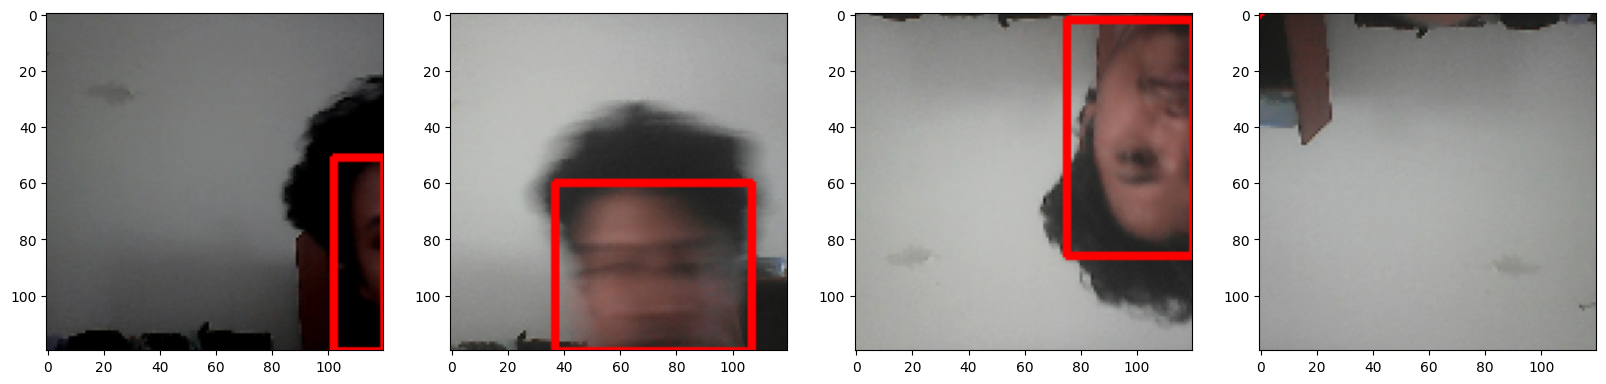

In [71]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = res[0][idx]
    sample_coords = res[1][1][idx]
    
    cv2.rectangle(sample_image, 
                  tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                  tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                        (255,0,0), 2)

    ax[idx].imshow(sample_image)

# 8. Build Deep Learning using the Functional API

### 8.1 Import Layers and Base Network

In [72]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D
from tensorflow.keras.applications import VGG16

### 8.2 Download VGG16

In [73]:
vgg = VGG16(include_top=False)

58889256/58889256 [==============================] - 26s 0us/step


In [74]:
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

### 8.3 Build instance of Network

In [75]:
def build_model(): 
    input_layer = Input(shape=(120,120,3))
    
    vgg = VGG16(include_top=False)(input_layer)

    # Classification Model  
    f1 = GlobalMaxPooling2D()(vgg)
    class1 = Dense(2048, activation='relu')(f1)
    class2 = Dense(1, activation='sigmoid')(class1)
    
    # Bounding box model
    f2 = GlobalMaxPooling2D()(vgg)
    regress1 = Dense(2048, activation='relu')(f2)
    regress2 = Dense(4, activation='sigmoid')(regress1)
    
    facetracker = Model(inputs=input_layer, outputs=[class2, regress2])
    return facetracker

### 8.4 Test out Neural Network

In [76]:
facetracker = build_model()

In [77]:
facetracker.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 120, 120, 3)]        0         []                            
                                                                                                  
 vgg16 (Functional)          (None, None, None, 512)      1471468   ['input_2[0][0]']             
                                                          8                                       
                                                                                                  
 global_max_pooling2d (Glob  (None, 512)                  0         ['vgg16[0][0]']               
 alMaxPooling2D)                                                                                  
                                                                                              

In [78]:
X, y = train.as_numpy_iterator().next()

In [79]:
X.shape

(8, 120, 120, 3)

In [80]:
classes, coords = facetracker.predict(X)

1/1 [==============================] - 1s 1s/step


In [81]:
classes, coords

(array([[0.5503823 ],
        [0.5110683 ],
        [0.51403874],
        [0.4837083 ],
        [0.559862  ],
        [0.57505316],
        [0.5600224 ],
        [0.5091793 ]], dtype=float32),
 array([[0.5419018 , 0.32776815, 0.5204375 , 0.5503297 ],
        [0.58933854, 0.34377006, 0.5243785 , 0.53685755],
        [0.6097137 , 0.32744873, 0.56849957, 0.48650137],
        [0.5912915 , 0.40185627, 0.5714297 , 0.5407708 ],
        [0.56219953, 0.32215062, 0.5140152 , 0.57483095],
        [0.59494215, 0.36416668, 0.55215704, 0.47228172],
        [0.552599  , 0.3829424 , 0.56648225, 0.5198192 ],
        [0.6088514 , 0.36447525, 0.51928836, 0.530048  ]], dtype=float32))

# 9. Define Losses and Optimizers

### 9.1 Define Optimizer and LR

In [96]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [106]:
opt = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001, decay=lr_decay)

### 9.2 Create Localization Loss and Classification Loss

In [97]:
def localization_loss(y_true, yhat):            
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))
                  
    h_true = y_true[:,3] - y_true[:,1] 
    w_true = y_true[:,2] - y_true[:,0] 

    h_pred = yhat[:,3] - yhat[:,1] 
    w_pred = yhat[:,2] - yhat[:,0] 
    
    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))
    
    return delta_coord + delta_size

In [98]:
classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

### 9.3 Test out Loss Metrics

In [99]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=4.0038075>

In [100]:
classloss(y[0], classes)

<tf.Tensor: shape=(), dtype=float32, numpy=0.64358294>

In [101]:
regressloss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=4.0038075>

# 10. Train Neural Network

### 10.1 Create Custom Model Class

In [102]:
class FaceTracker(Model): 
    def __init__(self, eyetracker,  **kwargs): 
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt
    
    def train_step(self, batch, **kwargs): 
        
        X, y = batch
        
        with tf.GradientTape() as tape: 
            classes, coords = self.model(X, training=True)
            
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
            
            total_loss = batch_localizationloss+0.5*batch_classloss
            
            grad = tape.gradient(total_loss, self.model.trainable_variables)
        
        opt.apply_gradients(zip(grad, self.model.trainable_variables))
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
    
    def test_step(self, batch, **kwargs): 
        X, y = batch
        
        classes, coords = self.model(X, training=False)
        
        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
        
    def call(self, X, **kwargs): 
        return self.model(X, **kwargs)

In [103]:
model = FaceTracker(facetracker)

In [107]:
model.compile(opt, classloss, regressloss)

### 10.2 Train

In [108]:
logdir='logs'

In [109]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train, epochs=10, validation_data=val, callbacks=[tensorboard_callback]) 

### 10.3 Plot Performance

In [ ]:
hist.history

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

# 11. Make Predictions

### 11.1 Make Predictions on Test Set

In [ ]:
test_data = test.as_numpy_iterator()

In [ ]:
test_sample = test_data.next()

In [ ]:
yhat = facetracker.predict(test_sample[0])

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = test_sample[0][idx]
    sample_coords = yhat[1][idx]
    
    if yhat[0][idx] > 0.9:
        cv2.rectangle(sample_image, 
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                            (255,0,0), 2)
    
    ax[idx].imshow(sample_image)

### 11.2 Save the Model

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
facetracker.save('facetracker.h5')

In [ ]:
facetracker = load_model('facetracker.h5')

### 11.3 Real Time Detection

In [ ]:
cap = cv2.VideoCapture(1)
while cap.isOpened():
    _ , frame = cap.read()
    frame = frame[50:500, 50:500,:]
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))
    
    yhat = facetracker.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[1][0]
    
    if yhat[0] > 0.5: 
        # Controls the main rectangle
        cv2.rectangle(frame, 
                      tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)), 
                            (255,0,0), 2)
        # Controls the label rectangle
        cv2.rectangle(frame, 
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), 
                                    [0,-30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                    [80,0])), 
                            (255,0,0), -1)
        
        # Controls the text rendered
        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                               [0,-5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
    
    cv2.imshow('EyeTrack', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()